# 第四讲：Pandas 时间序列入门

## 先搞清楚：Pandas 是什么？

你已经学了 NumPy（数组运算）。Pandas 是 NumPy 的「亲戚」——它基于 NumPy 构建，但专门为**表格数据**设计。

| | NumPy | Pandas |
|---|---|---|
| 核心数据结构 | `ndarray`（数组） | `DataFrame`（表格）、`Series`（一列） |
| 类比 | 计算器 | Excel 表格 |
| 索引 | 数字位置 (0,1,2...) | 可以自定义标签（如日期、股票代码） |
| 列名 | 没有 | 有（每列有自己的名字） |

**简单说：NumPy 处理「数字矩阵」，Pandas 处理「带标签的表格」。**

一个 DataFrame 长这样：

```
            open    high     low   close    volume
date                                              <- 这是「索引」列
2024-01-02  100.5   102.3   99.8   101.2   5000000
2024-01-03  101.2   103.1  100.9   102.8   6200000
2024-01-04  102.8   104.0  101.5   103.5   4800000
           ^^^^^   ^^^^^   ^^^^   ^^^^^   ^^^^^^^
           这五个是「列」，每列有名字
```

**学习目标**
- 理解 DataFrame/Series 的本质（它和 NumPy array 的关系）
- 掌握时间索引操作（`.loc` 按标签找、`.iloc` 按位置找）
- 能处理缺失值和异常值
- 理解 resample（改频率）vs rolling（滑动窗口）的本质区别
- 为量化分析打下数据处理基础

---


─── 导入工具箱 ───pandas：处理表格数据的核心库，约定缩写为 pdnumpy：底层计算引擎matplotlib：画图库%matplotlib inline 是一个「魔法命令」：让图表直接显示在 notebook 里如果没有这行，图表会弹出一个新窗口显示设置中文字体——否则图表标题和标签会变成方块

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False  # 让负号 - 正常显示
print(f"pandas 版本: {pd.__version__}")
print(f"numpy 版本: {np.__version__}")


## 4.1 创建时间序列数据

在量化分析中，几乎所有数据都带时间戳。`pd.date_range()` 是创建时间索引的核心工具。

─── pd.date_range()：创建连续日期序列 ───这是 pandas 里最基础的时间工具，类比 Excel 里拖拽填充日期参数：start=开始日期, end=结束日期, freq=频率, periods=生成多少个1. 创建日期范围（最常用）freq='D' = Daily（每天），'B' = Business day（工作日，跳过周末）2. 不同频率的日期范围频率代码：W=周, ME=月末, QE=季末, B=工作日periods=5 意思是「生成 5 个日期」，不需要指定 end观察：1月1日是周一，所以周一到周五都出现了，但周六日被跳过

In [ ]:
dates = pd.date_range(start='2024-01-01', end='2024-01-10', freq='D')
print("日频日期范围（D=每天）:")
print(dates)
print("\n---\n")
print("周频 (W): 每周日")
print(pd.date_range('2024-01-01', periods=5, freq='W'))
print("\n月频 (ME): 每月最后一天")
print(pd.date_range('2024-01-01', periods=5, freq='ME'))
print("\n季度 (QE): 每季度最后一天")
print(pd.date_range('2024-01-01', periods=4, freq='QE'))
print("\n工作日 (B): 跳过周末")
print(pd.date_range('2024-01-01', periods=10, freq='B'))


─── 创建模拟的股价 DataFrame ───DataFrame 是 pandas 的核心：一个有行名和列名的二维表格可以想象成 Excel 表格，但功能强大得多1. 创建 100 个连续工作日作为索引2. 生成模拟的 OHLC 数据np.random 生成随机数模拟股价波动cumsum() 是「累积和」：从起点开始不断加随机变化，模拟价格走势randn(n) 生成 n 个标准正态随机数，*0.5 缩小波动幅度cumsum 把它们累加起来，形成一条模拟的价格曲线构建 DataFrame：用字典指定每一列的数据pd.DataFrame({列名: 数据, ...}, index=行名)生成 high 和 low：取 open 和 close 中较大的为 high，较小的为 lowdf[['open', 'close']] 选中两列，.max(axis=1) 在每一行上取最大值

In [ ]:
dates = pd.date_range('2024-01-01', periods=100, freq='B')
print(f"生成了 {len(dates)} 个工作日")
np.random.seed(42)  # 固定种子，保证每次运行结果一样
n = len(dates)
base_price = 100 + np.cumsum(np.random.randn(n) * 0.5)
df = pd.DataFrame({
    'open':  base_price + np.random.uniform(-0.3, 0.3, n),
    'close': base_price + np.random.uniform(-0.3, 0.3, n),
    'volume': np.random.randint(100000, 1000000, n),
}, index=dates)  # index=dates 把日期设为行名
df['high'] = df[['open', 'close']].max(axis=1) + np.random.uniform(0.1, 0.5, 100)
df['low']  = df[['open', 'close']].min(axis=1) - np.random.uniform(0.1, 0.5, 100)
print(f"DataFrame 形状: {df.shape}")     # .shape 返回 (行数, 列数)
print(f"索引类型: {type(df.index)}")      # DatetimeIndex = 日期索引
print(f"索引频率: {df.index.freq}")       # 如果是规则频率会显示，否则 None
df.head(10)  # .head(n) 显示前 n 行，默认 5 行


## 4.2 时间索引操作

DatetimeIndex 支持非常灵活的切片和查询方式，比普通整数索引强大得多。

─── 时间索引操作 ───DataFrame 有两种索引方式：  .loc[行标签, 列标签]  —— 用「名字」找（类似 Excel 里点行列标题）  .iloc[行位置, 列位置] —— 用「数字编号」找（从 0 开始）1. 基于标签的索引 .loc —— 最常用因为我们的索引是日期，所以可以直接用日期字符串定位2. 日期范围切片 —— 和 Python 列表切片一样用冒号注意：loc 的范围切片是「两端都包含」的！3. 基于位置的索引 .iloc —— 按数字位置.iloc[行, 列] 和 NumPy 数组索引一样，从 0 开始

In [ ]:
print("2024-01-03 这一天的数据:")
print(df.loc['2024-01-03'])  # 找到索引标签恰好是 '2024-01-03' 的那一行
print("\n---\n")
print("2024年1月前5个交易日:")
print(df.loc['2024-01-01':'2024-01-07'])
print("\n---\n")
print("前3行、最后2列:")
print(df.iloc[:3, -2:])  # 前3行（0,1,2），最后2列


─── 更多索引技巧 ───4. 部分字符串匹配 —— pandas 的日期索引很聪明写 '2024-01' 就自动匹配 2024 年 1 月的所有日期5. 同时筛选行和列：.loc[行, 列]冒号左边是行范围，右边是列名6. 布尔索引（条件筛选）—— 量化分析里天天用df[条件] 返回所有满足条件（True）的行 df['volume'] > 400000 返回一列 True/False df[True/False列表] 只保留 True 的行

In [ ]:
print("2024年1月所有数据（前5行）:")
print(df.loc['2024-01'].head())
print("\n---\n")
print("2024-01-03 到 2024-01-08 的收盘价:")
print(df.loc['2024-01-03':'2024-01-08', 'close'])
print("\n---\n")
print("成交量大于 400000 的天数:")
print(df[df['volume'] > 400000].head())


## 4.3 缺失值处理

真实数据一定有缺失。先学会识别，再学会填补。
### 为什么会有缺失值？

- 股票停牌 → 当天没有交易数据
- 数据源本身有缺口
- 不同数据源合并时日期对不齐

缺失值是真实数据不可避免的一部分。**发现缺失值 → 理解为什么缺失 → 选择填补策略**，这是数据分析的标准流程。


In [ ]:
# 故意制造一些缺失值
df_missing = df.copy()
df_missing.loc['2024-01-05', 'close'] = np.nan
df_missing.loc['2024-01-08', 'volume'] = np.nan
df_missing.loc['2024-01-10':'2024-01-12', 'open'] = np.nan

# 1. 检查缺失值
print("缺失值总数（按列）:")
print(df_missing.isnull().sum())

print("\n有缺失值的行:")
print(df_missing[df_missing.isnull().any(axis=1)])

─── 缺失值处理演示 ───1. 人为制造一些缺失值（模拟真实数据的情况）NaN = Not a Number，是 pandas 表示缺失值的标准方式2. 检查缺失值any(axis=1) 检查每一行「是否有任何列是 NaN」3. 填补策略策略A：前向填充（用前一天的数值填补）ffill = forward fill：向下找最近的非 NaN 值来填补策略B：后向填充（用后一天的数值填补）策略C：线性插值（用前后数据的平均值来估算）策略D：直接删除有缺失的行（最暴力，慎用）dropna() 默认删除任何包含 NaN 的行

In [ ]:
df_missing = df.copy()  # .copy() 创建一个独立的副本，不影响原 DataFrame
df_missing.iloc[5:10, 2] = np.nan   # 第 5-9 行的第 2 列（high）设为 NaN
df_missing.iloc[20:25, 4] = np.nan  # 第 20-24 行的第 4 列（volume）设为 NaN
print("各列缺失值统计:")
print(df_missing.isnull().sum())  # isnull() 返回 True/False，sum() 数 True 的个数
print(f"\n有任何缺失值的行数: {df_missing.isnull().any(axis=1).sum()}")
print("\n缺失值所在的行（high 列为 NaN 的）:")
print(df_missing[df_missing['high'].isnull()])
print("\n--- 填补策略 ---")
df_ffill = df_missing.ffill()
print("前向填充后，high 列剩余缺失值:", df_ffill['high'].isnull().sum())
df_bfill = df_missing.bfill()
print("后向填充后，high 列剩余缺失值:", df_bfill['high'].isnull().sum())
df_interp = df_missing.interpolate()
print("线性插值后，high 列剩余缺失值:", df_interp['high'].isnull().sum())
df_dropped = df_missing.dropna()
print(f"删除缺失行后，形状从 {df_missing.shape} 变成 {df_dropped.shape}")


In [ ]:
# 3. 直接删除有缺失值的行（最暴力的方法）
df_dropped = df_missing.dropna()
print(f"删除前: {len(df_missing)} 行")
print(f"删除后: {len(df_dropped)} 行")
print(f"删除了 {len(df_missing) - len(df_dropped)} 行")

## 4.4 异常值检测与处理

异常值会严重扭曲均值和回归模型。两种经典方法：IQR 和 Z-score。

─── IQR 异常值检测 ───IQR = Inter-Quartile Range（四分位距）Q1 = 第 25 百分位，Q3 = 第 75 百分位IQR = Q3 - Q1异常值界限：< Q1 - 1.5*IQR  或  > Q3 + 1.5*IQR找出异常值

In [ ]:
close = df['close']
Q1 = close.quantile(0.25)  # 第 25 百分位：25% 的数据比它小
Q3 = close.quantile(0.75)  # 第 75 百分位
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR  # 下界
upper_bound = Q3 + 1.5 * IQR  # 上界
print(f"Q1 (25%): {Q1:.2f}")
print(f"Q3 (75%): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"正常范围: [{lower_bound:.2f}, {upper_bound:.2f}]")
outliers = close[(close < lower_bound) | (close > upper_bound)]
print(f"\n异常值数量: {len(outliers)}")
print(f"异常值占比: {len(outliers)/len(close)*100:.1f}%")
if len(outliers) > 0:
    print(f"\n异常值:")
    print(outliers)


In [ ]:
# 方法1：IQR（四分位距）法 —— 稳健，不受极端值影响
Q1 = df_outlier['close'].quantile(0.25)
Q3 = df_outlier['close'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = (df_outlier['close'] < lower_bound) | (df_outlier['close'] > upper_bound)
print(f"IQR 法: lower={lower_bound:.2f}, upper={upper_bound:.2f}")
print(f"检测到的异常值:\n{df_outlier[outliers_iqr][['close']]}")

print("\n---\n")

# 方法2：Z-score 法 —— 假设数据服从正态分布
from scipy import stats
z_scores = np.abs(stats.zscore(df_outlier['close'].dropna()))
outliers_z = z_scores > 3  # 超过 3 个标准差视为异常
print(f"Z-score 法检测到的异常值数量: {outliers_z.sum()}")

In [ ]:
# 处理异常值：截断（clip）
df_clean = df_outlier.copy()
df_clean['close'] = df_clean['close'].clip(lower=lower_bound, upper=upper_bound)

print("处理前（含异常值）:")
print(df_outlier.loc['2024-01-14':'2024-01-16', 'close'])
print("\n处理后（clip 截断）:")
print(df_clean.loc['2024-01-14':'2024-01-16', 'close'])

## 4.5 resample —— 改变时间频率

**resample** 是把数据从一个时间频率「重采样」到另一个频率。

- **降采样**（高频→低频）：如日线→周线，需要用聚合函数（mean、sum、last 等）
- **升采样**（低频→高频）：如周线→日线，需要插值填充

─── resample：改变时间频率 ───把日线数据聚合成周线、月线语法：df.resample('频率').聚合函数()'W' = 每周，.last() = 取每周最后一天的值（周五或周三，取决于日历）

In [16]:
print("=== 降采样：日线 -> 周线 ===")
weekly = df.resample('W').agg({
    'open': 'first',    # 本周开盘价 = 周一开盘价
    'high': 'max',      # 本周最高价
    'low': 'min',       # 本周最低价
    'close': 'last',    # 本周收盘价
    'volume': 'sum',    # 本周成交量总和
})
print(f"周线形状: {weekly.shape}")
weekly.head()
print("\n=== 月线 ===")
monthly = df.resample('ME').agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum',
})
print(f"月线形状: {monthly.shape}")
monthly.head()


周线数据:
                  收盘价         均价         最高         最低
2024-01-07  12.748719  11.620134  12.748719  10.505168
2024-01-14  15.536832  14.444210  15.536832  13.346304
2024-01-21  18.270973  17.143752  18.270973  16.080729
2024-01-28  20.939463  19.894946  20.939463  18.840570
2024-02-04  23.755345  22.621460  23.755345  21.494386

---

月末收盘价:
2024-01-31    22.631865
2024-02-29    34.015903
2024-03-31    45.585329
2024-04-30    57.576407
2024-05-31    64.911489
Freq: ME, Name: close, dtype: float64


In [17]:
# 升采样：周线 → 日线（需要填充缺失的日期）
weekly_sample = df['close'].resample('W').last()  # 先得到周线
print(f"周线共 {len(weekly_sample)} 条")

# 升采样到日频，分别用不同方法填充
daily_ffill = weekly_sample.resample('D').ffill()      # 前向填充
daily_interp = weekly_sample.resample('D').interpolate() # 线性插值

print("\n前向填充（阶梯状）:")
print(daily_ffill.head(14))
print("\n线性插值（平滑过渡）:")
print(daily_interp.head(14))

周线共 20 条

前向填充（阶梯状）:
2024-01-07    12.748719
2024-01-08    12.748719
2024-01-09    12.748719
2024-01-10    12.748719
2024-01-11    12.748719
2024-01-12    12.748719
2024-01-13    12.748719
2024-01-14    15.536832
2024-01-15    15.536832
2024-01-16    15.536832
2024-01-17    15.536832
2024-01-18    15.536832
2024-01-19    15.536832
2024-01-20    15.536832
Freq: D, Name: close, dtype: float64

线性插值（平滑过渡）:
2024-01-07    12.748719
2024-01-08    13.147021
2024-01-09    13.545323
2024-01-10    13.943625
2024-01-11    14.341927
2024-01-12    14.740228
2024-01-13    15.138530
2024-01-14    15.536832
2024-01-15    15.927424
2024-01-16    16.318015
2024-01-17    16.708607
2024-01-18    17.099198
2024-01-19    17.489790
2024-01-20    17.880381
Freq: D, Name: close, dtype: float64


In [18]:
# OHLC 重采样（K线数据 resample）
weekly_ohlc = df['close'].resample('W').ohlc()
print("周线 OHLC:")
print(weekly_ohlc.head())

周线 OHLC:
                 open       high        low      close
2024-01-07  10.505168  12.748719  10.505168  12.748719
2024-01-14  13.346304  15.536832  13.346304  15.536832
2024-01-21  16.080729  18.270973  16.080729  18.270973
2024-01-28  18.840570  20.939463  18.840570  20.939463
2024-02-04  21.494386  23.755345  21.494386  23.755345


## 4.6 rolling —— 滚动窗口计算

**rolling** 保持原频率不变，用一个固定大小的窗口在数据上「滑动」，每滑动一步计算一次统计量。

这是计算均线、波动率、布林带等技术指标的基础。

─── rolling：滚动窗口计算 ───保持原频率不变，用一个「滑动窗口」在数据上移动语法：df.rolling(window=N).聚合函数()类比：你在看一部电影，不是快进（resample），而是透过一个窗口看窗口大小固定（比如 20 天），但每次移动一格（1 天）计算 5 日和 20 日移动平均（均线）关键理解：前 N-1 天没有足够数据，结果会是 NaN比如 MA20 的前 19 天都是 NaN——这很正常！计算滚动波动率（标准差）画图：收盘价 + 5日线 + 20日线下面画波动率

In [19]:
df['MA5']  = df['close'].rolling(window=5).mean()
df['MA20'] = df['close'].rolling(window=20).mean()
df['volatility_20'] = df['close'].rolling(window=20).std()
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(df.index, df['close'], alpha=0.5, label='收盘价', linewidth=0.8)
axes[0].plot(df.index, df['MA5'], label='MA5 (5日均线)', linewidth=1.2)
axes[0].plot(df.index, df['MA20'], label='MA20 (20日均线)', linewidth=1.2)
axes[0].set_title('收盘价与移动平均线', fontsize=13)
axes[0].legend()
axes[0].set_ylabel('价格')
axes[1].plot(df.index, df['volatility_20'], color='orange', linewidth=1.2)
axes[1].set_title('20日滚动波动率', fontsize=13)
axes[1].set_ylabel('波动率（标准差）')
plt.tight_layout()
plt.show()


含滚动指标的数据（前20行有 NaN 是因为窗口还没填满）:


,close,MA5,MA10,MA20,std_5,std_20
2024-01-01,10.505168,NaN,NaN,NaN,NaN,NaN
2024-01-02,11.058304,NaN,NaN,NaN,NaN,NaN
2024-01-03,11.612367,NaN,NaN,NaN,NaN,NaN
2024-01-04,12.176110,NaN,NaN,NaN,NaN,NaN
2024-01-05,12.748719,11.620134,NaN,NaN,0.886239,NaN
2024-01-08,13.346304,12.188361,NaN,NaN,0.903297,NaN
2024-01-09,13.897935,12.756287,NaN,NaN,0.907840,NaN
2024-01-10,14.430230,13.319860,NaN,NaN,0.894729,NaN
2024-01-11,15.009749,13.886587,NaN,NaN,0.886541,NaN
2024-01-12,15.536832,14.444210,13.032172,NaN,0.868572,NaN


In [20]:
# 自定义滚动函数：计算滚动最大回撤
def rolling_max_drawdown(series):
    """计算窗口内的最大回撤"""
    cumulative_max = series.cummax()
    drawdown = (series - cumulative_max) / cumulative_max
    return drawdown.min()

df['max_dd_10'] = df['close'].rolling(window=10).apply(rolling_max_drawdown)
print("滚动最大回撤 (10日窗口):")
df[['close', 'max_dd_10']].dropna().head(10)

滚动最大回撤 (10日窗口):


,close,max_dd_10
2024-01-12,15.536832,0.0
2024-01-15,16.080729,0.0
2024-01-16,16.588575,0.0
2024-01-17,17.091110,0.0
2024-01-18,17.687375,0.0
2024-01-19,18.270973,0.0
2024-01-22,18.840570,0.0
2024-01-23,19.381465,0.0
2024-01-24,19.898795,0.0
2024-01-25,20.414439,0.0


## 4.7 resample vs rolling —— 本质区别

| | resample | rolling |
|---|---|---|
| **操作** | 改变频率 | 保持频率 |
| **输出行数** | 变少（降采样）或变多（升采样） | 不变 |
| **用途** | 日→周、日→月、高频→低频 | 均线、波动率、布林带 |
| **类比** | 把日报汇总成周报 | 看过去5天的平均情况 |

下面用一张图直观对比：
### 一句话记住

> **resample = 改时间单位（日→周），数据变少了。**
> **rolling = 不改时间单位，每个点都是一个窗口的统计值，数据不变少。**

类比：resample 是把 30 天的日报编成 1 本月报（压缩）。rolling 是拿一个 7 天的窗口逐日滑动，每天都有一个「过去 7 天的平均值」。


对比图：resample vs rolling上图：rolling —— 同频率、平滑曲线下图：resample —— 变频率、数据点变少

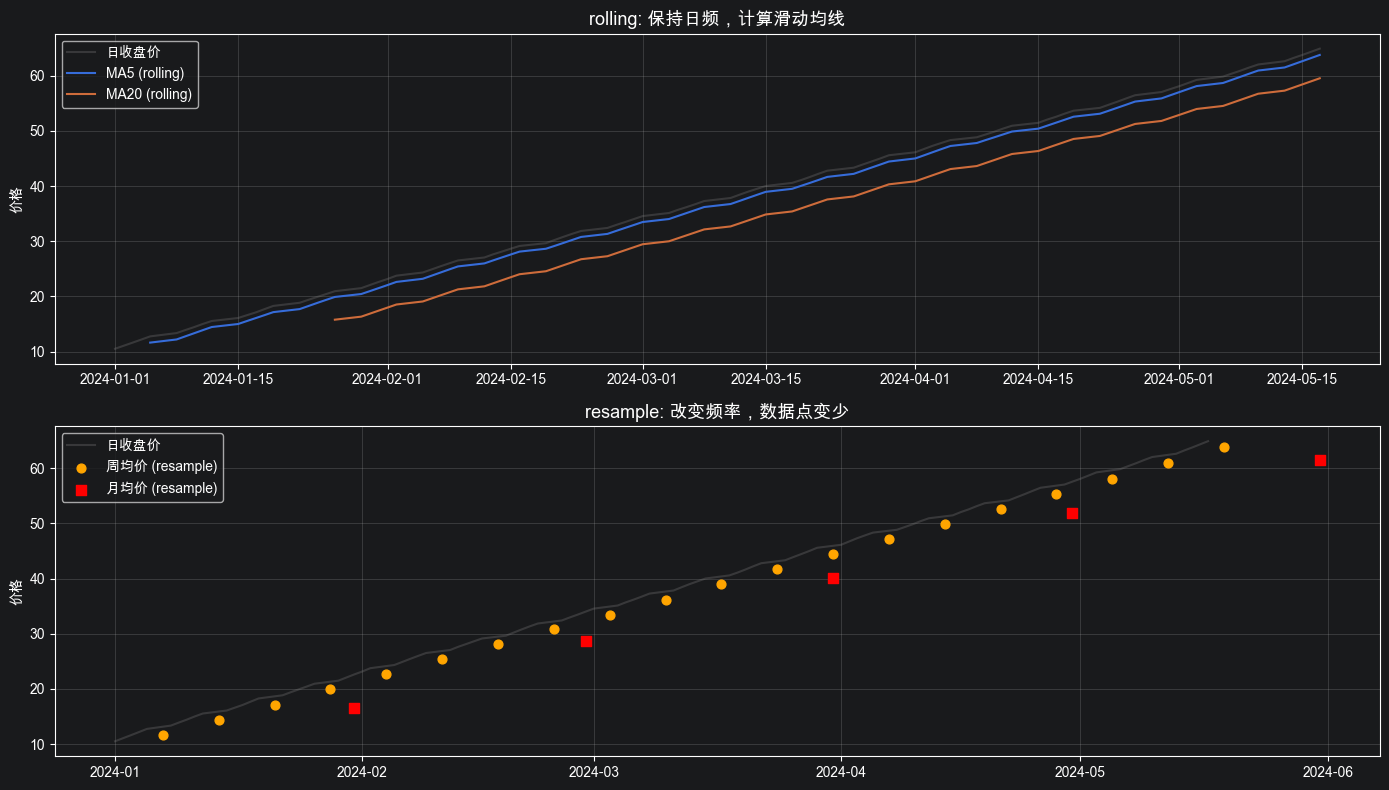

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
ax1 = axes[0]
ax1.plot(df.index, df['close'], alpha=0.3, label='日收盘价', color='gray')
ax1.plot(df.index, df['MA5'], label='MA5 (rolling)', linewidth=1.5)
ax1.plot(df.index, df['MA20'], label='MA20 (rolling)', linewidth=1.5)
ax1.set_title('rolling: 保持日频，计算滑动均线', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left')
ax1.set_ylabel('价格')
ax1.grid(True, alpha=0.3)
ax2 = axes[1]
weekly_mean = df['close'].resample('W').mean()
monthly_mean = df['close'].resample('ME').mean()
ax2.plot(df.index, df['close'], alpha=0.3, label='日收盘价', color='gray')
ax2.scatter(weekly_mean.index, weekly_mean, label='周均价 (resample)', 
           color='orange', s=40, zorder=5)
ax2.scatter(monthly_mean.index, monthly_mean, label='月均价 (resample)', 
           color='red', s=60, zorder=5, marker='s')
ax2.set_title('resample: 改变频率，数据点变少', fontsize=13, fontweight='bold')
ax2.legend(loc='upper left')
ax2.set_ylabel('价格')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4.8 小结

| 技能 | 掌握了吗？ |
|------|----------|
| 用 `pd.date_range()` 创建时间索引 | ☐ |
| 用 `.loc['2024-01']` 按日期切片 | ☐ |
| 用 `ffill()` 处理缺失值 | ☐ |
| 用 IQR 检测异常值 | ☐ |
| 用 `resample('W')` 做降采样 | ☐ |
| 用 `rolling(20).mean()` 计算均线 | ☐ |
| 能分清楚 resample 和 rolling 的区别 | ☐ |

**下一讲预告：** 用真实数据（AKShare 下载沪深300）实战均线和波动率计算。
### 📝 你的笔记区

在下面新建一个 Markdown Cell，写下：
- `.loc` 和 `.iloc` 的区别（用自己的话）
- resample 和 rolling 的区别（你以后面试会被问到！）
- 你今天遇到的一个 bug 和怎么解决的

---

**下一讲预告：** 用 AKShare 获取真实的沪深 300 行情，实战均线和波动率分析。
